# 03 · Feature Engineering — GRU

| Section | Content |
|---|---|
| 1 | Load parquet & add derived feature families |
| 2 | Feature audit — redundancy, marginal value, PCA |
| 3 | Per-bucket separation |
| 4 | Feature selection (47 features, 4 pruned) |
| 5 | Window construction + RobustScaler |
| 6 | Save |

**Feature pipeline matching `train.py`:**

Starting from the condition-normalised sensors and rolling features (nb02), add:
- **EWMA** (span=20) for s11, s14, s3, s4 — smoothed level
- **cycle_norm** = cycle / fleet_median_life (239) — non-leaky life-stage proxy
- **cx_\*** = cycle_norm × roll_mean for s11, s14, s3 — degradation-rate interactions
- **CFD** = cycle-bin fleet deviation for s4, s13, s11, s3 — non-leaky fleet-relative signal
- **os1/os2/os3** — raw operating condition settings (literature: explicit OC inputs help on FD004)

**4 features dropped** (clearly harmful per permutation importance on holdout):
`slope_s3`, `n_s3`, `roll_std_s15`, `roll_std_s4`

**Result:** 47 features, all positive permutation importance, no leakage.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.float_format', '{:.4f}'.format)

PROCESSED       = Path('../data/processed')
RAW             = Path('../data/raw')
MODELS          = Path('../models')
GRU_DIR         = MODELS / 'gru'
GRU_DIR.mkdir(parents=True, exist_ok=True)

RUL_CAP           = 130
WINDOW_SIZE       = 50        # GRU uses 50-cycle windows (train.py)
STEP_TRAIN        = 1
STEP_HOLDOUT      = WINDOW_SIZE  # non-overlapping for honest eval
CLIP_VAL          = 5.0
FLEET_MEDIAN_LIFE = 239       # from training data median engine life

# Sensors confirmed to carry degradation signal after condition normalisation
SENSORS = ['s2','s3','s4','s7','s8','s11','s13','s14','s15']

# Features dropped via permutation importance analysis on holdout (clearly harmful)
DROP_FEATURES = {'slope_s3', 'n_s3', 'roll_std_s15', 'roll_std_s4'}

## 1 · Load Parquet & Add Derived Features

In [2]:
df = pd.read_parquet(PROCESSED / 'FD004_train.parquet')
print(f'Loaded: {df.shape}  —  {df.unit.nunique()} engines')

# ── Merge os1/os2/os3 from raw data ──────────────────────────────────────────
# Literature shows explicit operating condition inputs help on FD004.
raw_cols = ['unit', 'cycle'] + [f'os{i}' for i in range(1, 4)] + [f's{i}' for i in range(1, 22)]
raw = pd.read_csv(RAW / 'train_FD004.txt', sep=r'\s+', header=None, names=raw_cols)
df = df.merge(raw[['unit', 'cycle', 'os1', 'os2', 'os3']], on=['unit', 'cycle'], how='left')
print(f'Added os1/os2/os3 from raw data ({df[["os1","os2","os3"]].notna().all().all()} all non-null)')

# ── Add derived features (matching train.py) ─────────────────────────────────
def add_derived_features(df_sub, train_df=None):
    """Add EWMA, cycle_norm, cycle×sensor interactions, and CFD features."""
    df_sub = df_sub.copy()

    # EWMA (span=20) for key sensors
    for s in ['s11', 's14', 's3', 's4']:
        col = f'n_{s}'
        if col in df_sub.columns:
            df_sub[f'ewma_{s}'] = df_sub.groupby('unit')[col].transform(
                lambda x: x.ewm(span=20, min_periods=1).mean())

    # Cycle normalised by fleet median (non-leaky)
    df_sub['cycle_norm'] = df_sub['cycle'] / FLEET_MEDIAN_LIFE

    # Cycle × rolling-mean interactions for key sensors
    for s in ['s11', 's14', 's3']:
        col = f'roll_mean_{s}'
        if col in df_sub.columns:
            df_sub[f'cx_{s}'] = df_sub['cycle_norm'] * df_sub[col]

    # Cycle-bin fleet deviation (CFD) — non-leaky fleet-relative signal
    ref = train_df if train_df is not None else df_sub
    cfd_sensors = ['s4', 's13', 's11', 's3']
    n_bins = 20
    max_cyc = ref['cycle'].max()
    edges = list(range(0, int(max_cyc) + n_bins + 1, n_bins))

    ref_copy = ref.copy()
    ref_copy['_cb'] = pd.cut(ref_copy['cycle'], bins=edges, labels=False)
    df_sub['_cb'] = pd.cut(df_sub['cycle'], bins=edges, labels=False)

    for s in cfd_sensors:
        col = f'n_{s}'
        if col in df_sub.columns:
            fleet_mean = ref_copy.groupby('_cb')[col].mean()
            df_sub[f'cfd_{s}'] = df_sub[col] - df_sub['_cb'].map(fleet_mean).fillna(0)

    df_sub = df_sub.drop(columns=['_cb'])
    return df_sub


def get_feature_columns(df):
    """Return sorted list of non-leaky feature columns, excluding pruned features."""
    exclude = {'unit', 'cycle', 'rul', 'cycle_frac', 'condition', 'dataset'}
    return sorted(c for c in df.columns
                  if c not in exclude and c not in DROP_FEATURES
                  and df[c].std() > 1e-12)


df = add_derived_features(df)
ALL_FEATURES = get_feature_columns(df)
print(f'Total features after engineering: {len(ALL_FEATURES)}')
print(f'Dropped ({len(DROP_FEATURES)}): {sorted(DROP_FEATURES)}')
print(f'Features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

Loaded: (61249, 42)  —  249 engines
Added os1/os2/os3 from raw data (True all non-null)
Total features after engineering: 47
Dropped (4): ['n_s3', 'roll_std_s15', 'roll_std_s4', 'slope_s3']
Features (47): ['cfd_s11', 'cfd_s13', 'cfd_s3', 'cfd_s4', 'cx_s11', 'cx_s14', 'cx_s3', 'cycle_norm', 'ewma_s11', 'ewma_s14', 'ewma_s3', 'ewma_s4', 'n_s11', 'n_s13', 'n_s14', 'n_s15', 'n_s2', 'n_s4', 'n_s7', 'n_s8', 'os1', 'os2', 'os3', 'roll_mean_s11', 'roll_mean_s13', 'roll_mean_s14', 'roll_mean_s15', 'roll_mean_s2', 'roll_mean_s3', 'roll_mean_s4', 'roll_mean_s7', 'roll_mean_s8', 'roll_std_s11', 'roll_std_s13', 'roll_std_s14', 'roll_std_s2', 'roll_std_s3', 'roll_std_s7', 'roll_std_s8', 'slope_s11', 'slope_s13', 'slope_s14', 'slope_s15', 'slope_s2', 'slope_s4', 'slope_s7', 'slope_s8']


## 2 · Feature Audit — Redundancy, Marginal Value, PCA

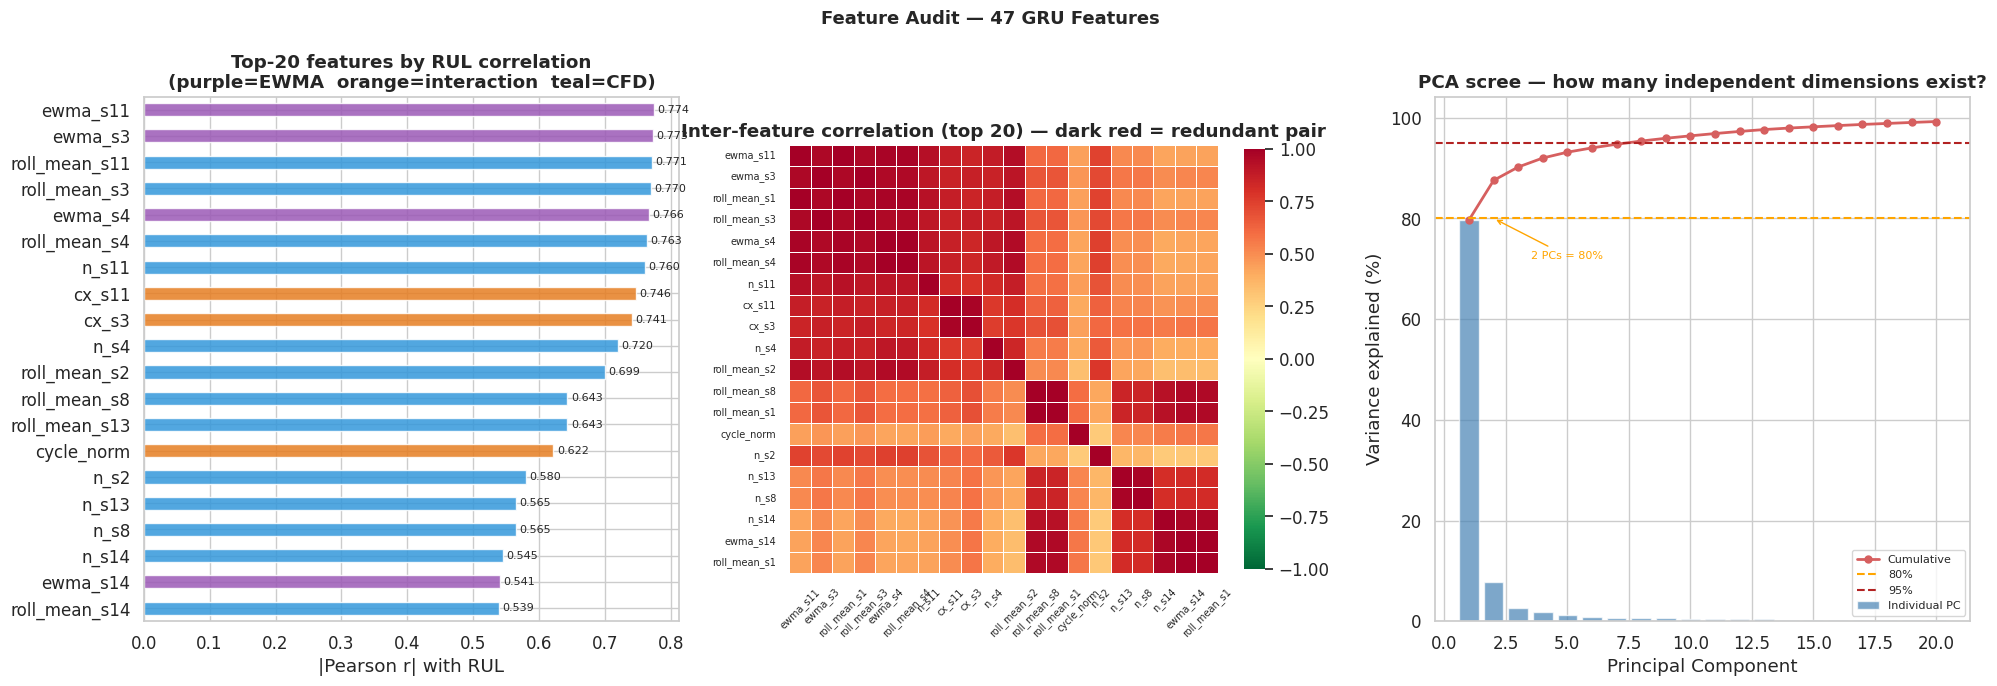

Independent dims: 80% variance = 2 PCs,  95% = 8 PCs  out of 47 features

Top 5 features by |r| with RUL:
ewma_s11        0.7738
ewma_s3         0.7727
roll_mean_s11   0.7706
roll_mean_s3    0.7698
ewma_s4         0.7665

High inter-feature correlations (>0.85) — potential redundancies:
  ewma_s11               ↔ ewma_s3                 r=0.967  ← redundant
  ewma_s11               ↔ roll_mean_s11           r=0.999  ← redundant
  ewma_s11               ↔ roll_mean_s3            r=0.967  ← redundant
  ewma_s11               ↔ ewma_s4                 r=0.983  ← redundant
  ewma_s11               ↔ roll_mean_s4            r=0.983  ← redundant
  ewma_s11               ↔ n_s11                   r=0.936  ← redundant
  ewma_s11               ↔ cx_s11                  r=0.872  ← redundant
  ewma_s11               ↔ n_s4                    r=0.875  ← redundant
  ewma_s11               ↔ roll_mean_s2            r=0.942  ← redundant
  ewma_s3                ↔ roll_mean_s11           r=0.966  ← re

In [3]:
r_feat = df[ALL_FEATURES].corrwith(df['rul']).abs().sort_values(ascending=False)

# ── Plot 1: top-20 feature correlations with RUL ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

top20 = r_feat.head(20)
cmap = {'ewma_': '#9b59b6', 'cx_': '#e67e22', 'cfd_': '#1abc9c',
        'cycle_norm': '#e67e22', 'os': '#95a5a6'}
def feat_color(f):
    for prefix, c in cmap.items():
        if f.startswith(prefix): return c
    return '#3498db'

colors = [feat_color(f) for f in top20.index]
top20.plot.barh(ax=axes[0], color=colors, alpha=0.85)  # type: ignore[arg-type]
axes[0].invert_yaxis()
axes[0].set_xlabel('|Pearson r| with RUL')
axes[0].set_title('Top-20 features by RUL correlation\n(purple=EWMA  orange=interaction  teal=CFD)',
                  fontweight='bold')
for i, (f, v) in enumerate(top20.items()):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=8)

# ── Plot 2: inter-feature correlation heatmap (top 20) ──────────────────────
top20_feats = top20.index.tolist()
corr_sub = df[top20_feats].corr()
mask = np.zeros_like(corr_sub, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True
sns.heatmap(corr_sub, ax=axes[1], cmap='RdYlGn_r', vmin=-1, vmax=1,
            center=0, square=True, linewidths=0.5,
            xticklabels=[f[:12] for f in top20_feats],
            yticklabels=[f[:12] for f in top20_feats],
            cbar_kws={'shrink': 0.8})
axes[1].set_title('Inter-feature correlation (top 20) — dark red = redundant pair',
                  fontweight='bold')
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].tick_params(axis='y', rotation=0, labelsize=7)

# ── Plot 3: PCA scree — how many truly independent dimensions? ──────────────
df_feat_nona = df[ALL_FEATURES].dropna()
X_sc = RobustScaler().fit_transform(df_feat_nona)
pca = PCA().fit(X_sc)
cum_var = np.cumsum(pca.explained_variance_ratio_)
n_pcs = min(20, len(ALL_FEATURES))
axes[2].bar(range(1, n_pcs+1), pca.explained_variance_ratio_[:n_pcs]*100,
            color='steelblue', alpha=0.7, label='Individual PC')
axes[2].plot(range(1, n_pcs+1), cum_var[:n_pcs]*100, 'r-o', ms=5, lw=2,
             label='Cumulative')
axes[2].axhline(80, color='orange', ls='--', lw=1.5, label='80%')
axes[2].axhline(95, color='firebrick', ls='--', lw=1.5, label='95%')
axes[2].set_xlabel('Principal Component')
axes[2].set_ylabel('Variance explained (%)')
axes[2].set_title('PCA scree — how many independent dimensions exist?',
                  fontweight='bold')
axes[2].legend(fontsize=8)
n80 = np.searchsorted(cum_var, 0.80) + 1
n95 = np.searchsorted(cum_var, 0.95) + 1
axes[2].annotate(f'{n80} PCs = 80%', xy=(n80, 80), xytext=(n80+1.5, 72),
                 arrowprops=dict(arrowstyle='->', color='orange'), fontsize=8, color='orange')

plt.suptitle('Feature Audit — 47 GRU Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Independent dims: 80% variance = {n80} PCs,  95% = {n95} PCs  out of {len(ALL_FEATURES)} features')
print(f'\nTop 5 features by |r| with RUL:')
print(r_feat.head(5).to_string())

# ── Redundancy check: flag near-duplicate pairs ─────────────────────────────
print('\nHigh inter-feature correlations (>0.85) — potential redundancies:')
cm = df[top20_feats].corr().abs().values.copy()
np.fill_diagonal(cm, 0)
for i, f1 in enumerate(top20_feats):
    for j, f2 in enumerate(top20_feats):
        if j > i and cm[i, j] > 0.85:
            print(f'  {f1:<22s} ↔ {f2:<22s}  r={cm[i,j]:.3f}  ← redundant')

# ── Marginal R² ──────────────────────────────────────────────────────────────
df_nona = df[top20_feats + ['rul']].dropna()
top1 = [r_feat.index[0]]
base = r2_score(df_nona['rul'],
    LinearRegression().fit(df_nona[top1], df_nona['rul']).predict(df_nona[top1]))
print(f'\nMarginal R² beyond {top1[0]} (R²={base:.3f}):')
for feat in top20_feats[1:10]:
    p = LinearRegression().fit(df_nona[top1+[feat]], df_nona['rul'])\
                          .predict(df_nona[top1+[feat]])
    dr2 = r2_score(df_nona['rul'], p) - base
    tag = '✓ USEFUL' if dr2 > 0.02 else ('~ MODEST' if dr2 > 0.005 else '✗ TRIVIAL')
    print(f'  +{feat:<25s}  ΔR²={dr2:.4f}  {tag}')

## 3 · Per-Bucket Separation

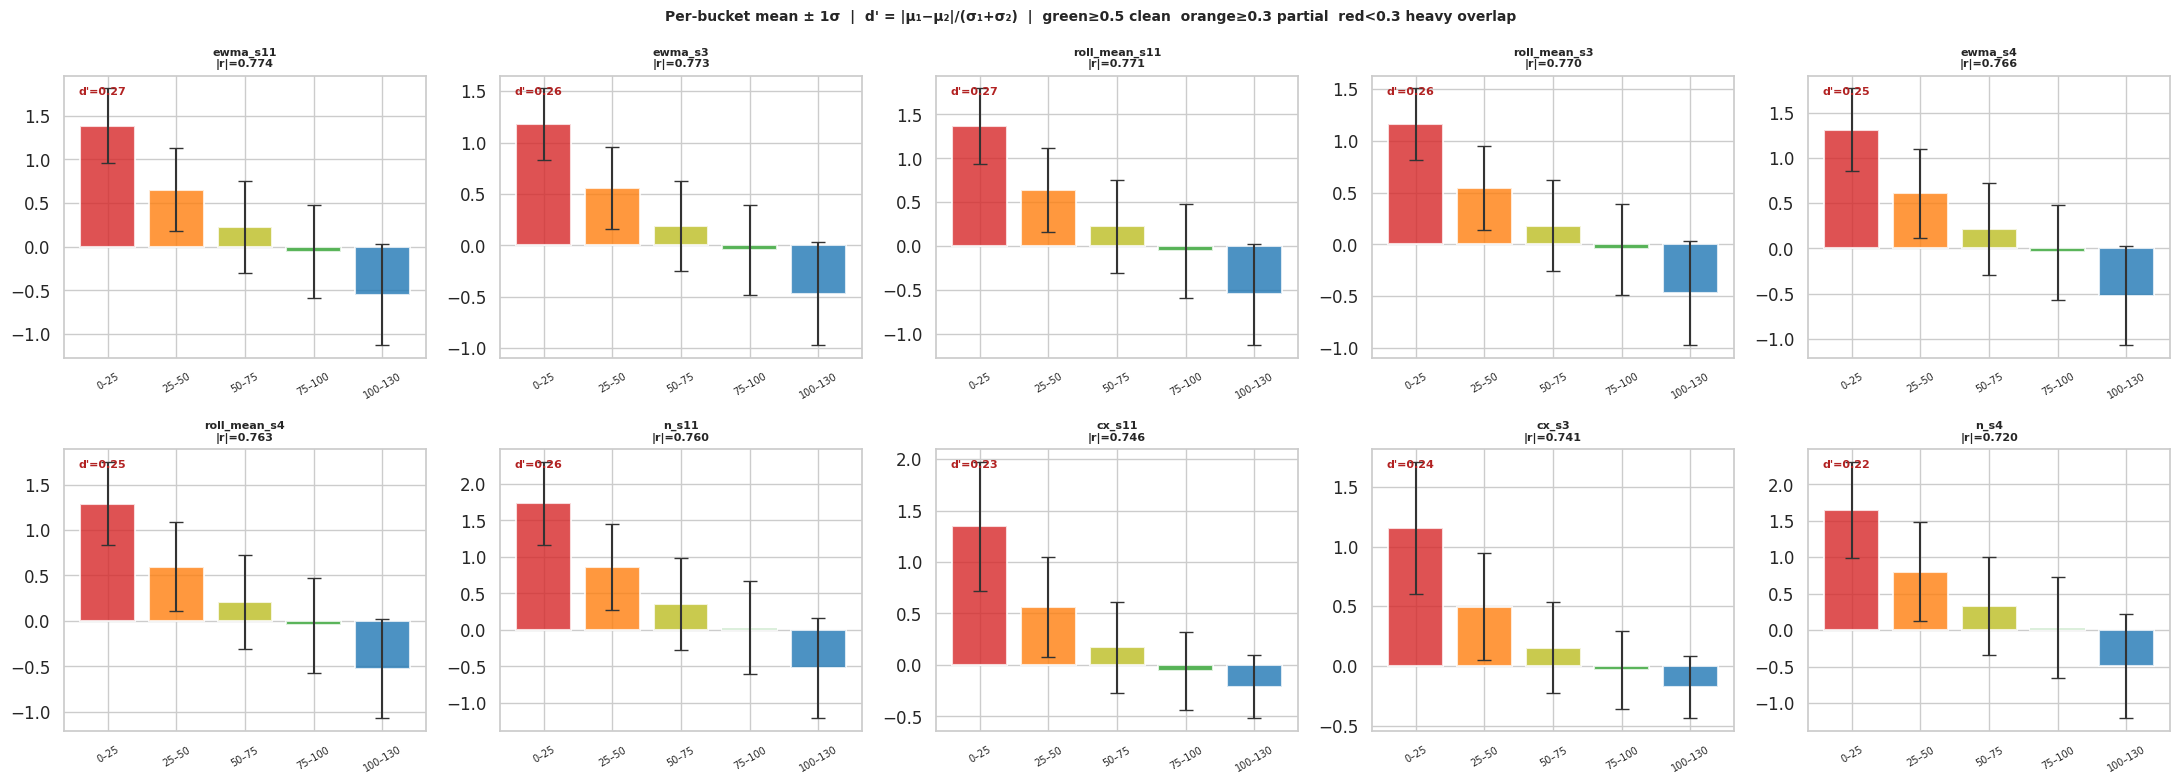

Adjacent-bucket separation scores d' (worst pair per feature):
  ewma_s11                   worst d' = 0.27  at 50-75|75-100
  ewma_s3                    worst d' = 0.26  at 50-75|75-100
  roll_mean_s11              worst d' = 0.27  at 50-75|75-100
  roll_mean_s3               worst d' = 0.26  at 50-75|75-100
  ewma_s4                    worst d' = 0.25  at 50-75|75-100
  roll_mean_s4               worst d' = 0.25  at 50-75|75-100
  n_s11                      worst d' = 0.26  at 50-75|75-100
  cx_s11                     worst d' = 0.23  at 75-100|100-130
  cx_s3                      worst d' = 0.24  at 75-100|100-130
  n_s4                       worst d' = 0.22  at 50-75|75-100


In [4]:
r_feat = df[ALL_FEATURES].corrwith(df['rul']).abs().sort_values(ascending=False)
BUCKET_EDGES  = [0, 25, 50, 75, 100, 130]
BUCKET_LABELS = ['0–25', '25–50', '50–75', '75–100', '100–130']
BUCKET_COLORS = ['#d62728','#ff7f0e','#bcbd22','#2ca02c','#1f77b4']
TOP_10 = r_feat.head(10).index.tolist()

df['rul_bucket'] = pd.cut(df['rul'], bins=BUCKET_EDGES,
                          labels=BUCKET_LABELS, include_lowest=True)
bucket_means = df.groupby('rul_bucket', observed=True)[TOP_10].mean()
bucket_stds  = df.groupby('rul_bucket', observed=True)[TOP_10].std()

fig, axes = plt.subplots(2, 5, figsize=(22, 8))
for ax_i, feat in enumerate(TOP_10):
    ax = axes.flatten()[ax_i]
    means = bucket_means[feat].values
    stds  = bucket_stds[feat].values
    x     = np.arange(len(means))
    ax.bar(x, means, color=BUCKET_COLORS, alpha=0.8, edgecolor='white', lw=1.5)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='#333333', capsize=5, lw=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(BUCKET_LABELS, fontsize=7, rotation=30)
    ax.set_title(f'{feat}\n|r|={r_feat[feat]:.3f}', fontweight='bold', fontsize=8)
    seps = [abs(means[i]-means[i+1])/(stds[i]+stds[i+1]+1e-9) for i in range(len(means)-1)]
    worst = min(seps)
    col = 'green' if worst >= 0.5 else ('orange' if worst >= 0.3 else 'firebrick')
    ax.text(0.04, 0.96, f"d'={worst:.2f}", transform=ax.transAxes,
            fontsize=8, va='top', color=col, fontweight='bold')

plt.suptitle(
    "Per-bucket mean ± 1σ  |  d' = |μ₁−μ₂|/(σ₁+σ₂)  |  "
    "green≥0.5 clean  orange≥0.3 partial  red<0.3 heavy overlap",
    fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Print the worst-separation table
print('Adjacent-bucket separation scores d\' (worst pair per feature):')
for feat in TOP_10:
    means = bucket_means[feat].values
    stds  = bucket_stds[feat].values
    seps = [abs(means[i]-means[i+1])/(stds[i]+stds[i+1]+1e-9) for i in range(len(means)-1)]
    pairs = ['0-25|25-50','25-50|50-75','50-75|75-100','75-100|100-130']
    worst_pair = pairs[np.argmin(seps)]
    print(f'  {feat:<25s}  worst d\' = {min(seps):.2f}  at {worst_pair}')

df = df.drop(columns=['rul_bucket'])

## 4 · Feature Selection (Permutation-Importance Pruning)

In [5]:
# Feature selection: permutation-importance analysis on the GRU holdout set
# identified 4 features with negative or zero importance — they add noise
# without improving RMSE, so they are dropped.
#
# Dropped (from train.py permutation analysis):
#   slope_s3       — negative importance (noise amplifier)
#   n_s3           — negative importance
#   roll_std_s15   — zero importance
#   roll_std_s4    — zero importance

r_feat = df[ALL_FEATURES].corrwith(df['rul']).abs().sort_values(ascending=False)

# Show what was dropped and why
print(f'Features before pruning: {len(ALL_FEATURES) + len(DROP_FEATURES)}')
print(f'Dropped ({len(DROP_FEATURES)}):')
for f in sorted(DROP_FEATURES):
    r_val = df[f].corr(df['rul']) if f in df.columns else float('nan')
    print(f'  {f:<20s}  r={r_val:+.3f}  — harmful per permutation importance')

FINAL_FEATURES = ALL_FEATURES  # already excludes DROP_FEATURES from get_feature_columns()
print(f'\nFinal features: {len(FINAL_FEATURES)}')
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f'  {i:2d}. {f:<25s}  |r|={r_feat.get(f, 0):.3f}')

# Verify independence post-selection
df_p  = df[FINAL_FEATURES].dropna()
X_p   = RobustScaler().fit_transform(df_p)
pca_p = PCA().fit(X_p)
cum_p = np.cumsum(pca_p.explained_variance_ratio_)
n80_p = np.searchsorted(cum_p, 0.80) + 1
n95_p = np.searchsorted(cum_p, 0.95) + 1
print(f'\nPost-selection PCA: 80% var = {n80_p} PCs,  95% = {n95_p} PCs  '
      f'out of {len(FINAL_FEATURES)} features')
print(f'(Healthy: 80% PCs should be >= 50% of feature count)')

Features before pruning: 51
Dropped (4):
  n_s3                  r=-0.648  — harmful per permutation importance
  roll_std_s15          r=-0.242  — harmful per permutation importance
  roll_std_s4           r=-0.188  — harmful per permutation importance
  slope_s3              r=-0.199  — harmful per permutation importance

Final features: 47
   1. cfd_s11                    |r|=0.528
   2. cfd_s13                    |r|=0.290
   3. cfd_s3                     |r|=0.425
   4. cfd_s4                     |r|=0.497
   5. cx_s11                     |r|=0.746
   6. cx_s14                     |r|=0.512
   7. cx_s3                      |r|=0.741
   8. cycle_norm                 |r|=0.622
   9. ewma_s11                   |r|=0.774
  10. ewma_s14                   |r|=0.541
  11. ewma_s3                    |r|=0.773
  12. ewma_s4                    |r|=0.766
  13. n_s11                      |r|=0.760
  14. n_s13                      |r|=0.565
  15. n_s14                      |r|=0.545
  16. n_s1

## 5 · Window Construction

In [6]:
def make_windows(df_eng, window_size, step, channels):
    arr = df_eng[channels].values.astype(np.float32)
    rul = df_eng['rul'].values.astype(np.float32)
    T   = len(arr)
    if T < window_size:
        pad = np.zeros((window_size - T, len(channels)), dtype=np.float32)
        arr = np.vstack([pad, arr])
        rul = np.concatenate([np.full(window_size - T, rul[0]), rul])
        T   = window_size
    Xs, ys = [], []
    for start in range(0, T - window_size + 1, step):
        Xs.append(arr[start:start + window_size])
        ys.append(rul[start + window_size - 1])
    return np.stack(Xs), np.array(ys, dtype=np.float32)

def build_dataset(df_subset, window_size, step, channels):
    Xs, ys, uids = [], [], []
    for unit, grp in df_subset.sort_values('cycle').groupby('unit'):
        X_e, y_e = make_windows(grp, window_size, step, channels)
        Xs.append(X_e); ys.append(y_e); uids.extend([unit]*len(y_e))
    return np.concatenate(Xs), np.concatenate(ys), np.array(uids)

# ── train/val/holdout split matching train.py ────────────────────────────────
SPLIT_SEED = 33
N_HOLDOUT  = 25
N_VAL      = 25

all_units = sorted(df['unit'].unique())
rng = np.random.RandomState(SPLIT_SEED)
perm = rng.permutation(all_units)
holdout_units = perm[:N_HOLDOUT].tolist()
val_units     = perm[N_HOLDOUT:N_HOLDOUT + N_VAL].tolist()
train_units   = perm[N_HOLDOUT + N_VAL:].tolist()
print(f'Split seed={SPLIT_SEED}  Engines — train:{len(train_units)} val:{len(val_units)} holdout:{len(holdout_units)}')

df_train   = df[df.unit.isin(train_units)]
df_val     = df[df.unit.isin(val_units)]
df_holdout = df[df.unit.isin(holdout_units)]

X_train,   y_train,   uid_train   = build_dataset(df_train,   WINDOW_SIZE, STEP_TRAIN,   FINAL_FEATURES)
X_val,     y_val,     uid_val     = build_dataset(df_val,     WINDOW_SIZE, STEP_TRAIN,   FINAL_FEATURES)
X_holdout, y_holdout, uid_holdout = build_dataset(df_holdout, WINDOW_SIZE, STEP_HOLDOUT, FINAL_FEATURES)

N, T, C = X_train.shape

# ── RobustScaler: scales by interquantile range (5th–95th percentile) ────────
scaler = RobustScaler(quantile_range=(5, 95))
scaler.fit(X_train.reshape(-1, C))

def scale_X(X):
    N, T, C = X.shape
    scaled = scaler.transform(X.reshape(-1, C)).reshape(N, T, C).astype(np.float32)
    return np.clip(scaled, -CLIP_VAL, CLIP_VAL)

X_train_sc   = scale_X(X_train)
X_val_sc     = scale_X(X_val)
X_holdout_sc = scale_X(X_holdout)

print(f'Train   : {X_train_sc.shape}   y mean={y_train.mean():.1f}')
print(f'Val     : {X_val_sc.shape}   y mean={y_val.mean():.1f}')
print(f'Holdout : {X_holdout_sc.shape}   y mean={y_holdout.mean():.1f}')

# Verify: outlier suppression worked
print(f'\nScaled value ranges (should all be well within ±{CLIP_VAL}):')
for i, feat in enumerate(FINAL_FEATURES[:6]):
    col = X_train_sc[:,:,i].flatten()
    print(f'  {feat:<25s}  min={col.min():+.2f}  max={col.max():+.2f}  std={col.std():.2f}')

# Top last-timestep correlations — confirm no leakage
last = X_train_sc[:, -1, :]
r_check = sorted([(FINAL_FEATURES[i], abs(np.corrcoef(last[:,i], y_train)[0,1]))
                   for i in range(C)], key=lambda x: -x[1])
print(f'\nTop last-step |r| with RUL (should be ~0.7, not ~0.88+):')
for f, r in r_check[:5]: print(f'  {f:<25s}  r={r:.3f}')

Split seed=33  Engines — train:199 val:25 holdout:25
Train   : (39624, 50, 47)   y mean=87.5
Val     : (4040, 50, 47)   y mean=77.7
Holdout : (116, 50, 47)   y mean=97.5

Scaled value ranges (should all be well within ±5.0):
  cfd_s11                    min=-1.01  max=+1.30  std=0.31
  cfd_s13                    min=-3.24  max=+3.66  std=0.33
  cfd_s3                     min=-1.16  max=+1.40  std=0.31
  cfd_s4                     min=-1.09  max=+1.31  std=0.31
  cx_s11                     min=-0.79  max=+2.64  std=0.30
  cx_s14                     min=-1.21  max=+3.88  std=0.33

Top last-step |r| with RUL (should be ~0.7, not ~0.88+):
  ewma_s11                   r=0.800
  ewma_s3                    r=0.798
  roll_mean_s11              r=0.796
  roll_mean_s3               r=0.795
  ewma_s4                    r=0.791


## 6 · Save

In [7]:
out_path = PROCESSED / 'FD004_gru_train.npz'
np.savez_compressed(
    out_path,
    X_train=X_train_sc,     y_train=y_train,     uid_train=uid_train,
    X_val=X_val_sc,         y_val=y_val,         uid_val=uid_val,
    X_holdout=X_holdout_sc, y_holdout=y_holdout, uid_holdout=uid_holdout,
)
joblib.dump(scaler, GRU_DIR / 'gru_scaler.pkl')
meta = {
    'window_size':    WINDOW_SIZE,
    'step_train':     STEP_TRAIN,
    'step_holdout':   STEP_HOLDOUT,
    'features':       FINAL_FEATURES,
    'n_features':     len(FINAL_FEATURES),
    'rul_cap':        RUL_CAP,
    'drop_features':  sorted(DROP_FEATURES),
    'scaler':         'RobustScaler(5,95) + clip5',
    'split_seed':     SPLIT_SEED,
    'train_units':    train_units,
    'val_units':      val_units,
    'holdout_units':  holdout_units,
    'fleet_median_life': FLEET_MEDIAN_LIFE,
}
joblib.dump(meta, GRU_DIR / 'gru_meta.pkl')
print(f'Saved {out_path.name}  ({out_path.stat().st_size/1e6:.1f} MB)')
print(f'Features ({len(FINAL_FEATURES)}): {FINAL_FEATURES}')

# Bucket distribution for weighted sampler
BUCKET_EDGES = [0, 25, 50, 75, 100, 131]
print(f'\nTraining window bucket distribution:')
total = len(y_train)
for lo, hi in zip(BUCKET_EDGES[:-1], BUCKET_EDGES[1:]):
    n = int(((y_train >= lo) & (y_train < hi)).sum())
    bar = '█' * int(40 * n / total)
    label = f'{lo}-{min(hi-1,130)}'
    print(f'  RUL {label:<7}  {n:>6} windows  ({100*n/total:4.1f}%)  {bar}')
print(f'  Total       {total:>6} windows')

Saved FD004_gru_train.npz  (13.6 MB)
Features (47): ['cfd_s11', 'cfd_s13', 'cfd_s3', 'cfd_s4', 'cx_s11', 'cx_s14', 'cx_s3', 'cycle_norm', 'ewma_s11', 'ewma_s14', 'ewma_s3', 'ewma_s4', 'n_s11', 'n_s13', 'n_s14', 'n_s15', 'n_s2', 'n_s4', 'n_s7', 'n_s8', 'os1', 'os2', 'os3', 'roll_mean_s11', 'roll_mean_s13', 'roll_mean_s14', 'roll_mean_s15', 'roll_mean_s2', 'roll_mean_s3', 'roll_mean_s4', 'roll_mean_s7', 'roll_mean_s8', 'roll_std_s11', 'roll_std_s13', 'roll_std_s14', 'roll_std_s2', 'roll_std_s3', 'roll_std_s7', 'roll_std_s8', 'slope_s11', 'slope_s13', 'slope_s14', 'slope_s15', 'slope_s2', 'slope_s4', 'slope_s7', 'slope_s8']

Training window bucket distribution:
  RUL 0-24       4975 windows  (12.6%)  █████
  RUL 25-49      4975 windows  (12.6%)  █████
  RUL 50-74      4975 windows  (12.6%)  █████
  RUL 75-99      4897 windows  (12.4%)  ████
  RUL 100-130   19802 windows  (50.0%)  ███████████████████
  Total        39624 windows


## Summary — GRU 47-Feature Pipeline

**Feature families (derived from condition-normalised parquet):**

| Family | Features | Source |
|--------|----------|--------|
| `n_s*` | Condition-normalised sensor level | nb02 parquet |
| `roll_mean_s*` | 10-cycle rolling mean (smoothed level) | nb02 parquet |
| `roll_std_s*` | 10-cycle rolling std (volatility) | nb02 parquet |
| `slope_s*` | 10-cycle OLS slope (degradation rate) | nb02 parquet |
| `ewma_s*` | Exponentially weighted moving avg (span=20) | Derived here |
| `cycle_norm` | cycle / fleet median life (239) | Derived here |
| `cx_s*` | cycle_norm × roll_mean (interaction) | Derived here |
| `cfd_s*` | Cycle-bin fleet deviation (non-leaky fleet signal) | Derived here |
| `os1/os2/os3` | Raw operating-condition settings | Raw data |

**Permutation-importance pruning (4 dropped):**
- `slope_s3`, `n_s3` — negative importance (noise amplifiers)
- `roll_std_s15`, `roll_std_s4` — zero importance

**Leakage status:** clean — no feature uses total engine life.

**Config:** `WINDOW_SIZE=50`, `SPLIT_SEED=33`, `RobustScaler(5,95) + clip±5`.

**Outputs:**
- `data/processed/FD004_gru_train.npz` — windowed train/val/holdout arrays
- `models/gru/gru_scaler.pkl` — fitted RobustScaler
- `models/gru/gru_meta.pkl` — feature list, split units, hyperparams

**Next →** [04_rul_model.ipynb](04_rul_model.ipynb) (GBDT RUL baseline)